# Walmart sales analysis

In [46]:
#importing necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [47]:
#load the data set
df = pd.read_csv('/content/WalmartSalesData.csv')

In [48]:
#what is the shape of data set
df.shape

(1000, 17)

In [49]:
#how data looks like
df.sample(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
70,393-65-2792,C,Naypyitaw,Normal,Male,Food and beverages,89.48,10,44.7400,939.5400,2019-01-06,12:46:00,Credit card,894.80,4.761905,44.7400,9.6
142,338-65-2210,C,Naypyitaw,Member,Female,Health and beauty,68.60,10,34.3000,720.3000,2019-02-05,19:57:00,Cash,686.00,4.761905,34.3000,9.1
239,478-06-7835,A,Yangon,Normal,Male,Fashion accessories,89.69,1,4.4845,94.1745,2019-01-11,11:20:00,Ewallet,89.69,4.761905,4.4845,4.9
322,372-94-8041,A,Yangon,Normal,Male,Health and beauty,15.26,6,4.5780,96.1380,2019-02-15,18:03:00,Ewallet,91.56,4.761905,4.5780,9.8
671,642-61-4706,B,Mandalay,Member,Male,Food and beverages,93.40,2,9.3400,196.1400,2019-03-30,16:34:00,Cash,186.80,4.761905,9.3400,5.5


In [50]:
# is their any null values?
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [51]:
# any dublicates?
df.duplicated().sum()

np.int64(0)

In [52]:
# what is the data type of each columns?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [53]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [54]:
# #i could reduces its memory consumption but i am leaving upto you.

print("Initial memory usage of the DataFrame:")
df.info(memory_usage='deep')

# Convert 'Date' and 'Time' columns to datetime and combine them
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])
df.drop(['Date', 'Time'], axis=1, inplace=True)

def reduce_memory_usage_optimized(df, verbose=True):
    """
    Iterate through suitable columns of a dataframe and modify the data type to reduce memory usage.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f'Memory usage of dataframe before specific optimization: {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type == object:
            # Check if converting to category makes sense (e.g., if unique values are less than 50% of total values)
            num_unique_values = len(df[col].unique())
            num_total_values = len(df[col])
            if num_unique_values / num_total_values < 0.5:
                df[col] = df[col].astype('category')
        elif str(col_type).startswith('int'):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type).startswith('float'):
            c_min = df[col].min()
            c_max = df[col].max()
            # Use float32 if the range allows, as float16 might lose too much precision for financial data
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f'Memory usage after specific optimization: {end_mem:.2f} MB')
        print(f'Decreased by {(100 * (start_mem - end_mem) / start_mem):.2f}%')
    return df

# Apply the optimized memory reduction to the DataFrame
df = reduce_memory_usage_optimized(df)

print("\nMemory usage after overall optimization:")
df.info(memory_usage='deep')


Initial memory usage of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null  

In [55]:
# do we have wrong format column name
df.columns #before

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Payment',
       'cogs', 'gross margin percentage', 'gross income', 'Rating',
       'DateTime'],
      dtype='object')

In [56]:
# after
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender',
       'product_line', 'unit_price', 'quantity', 'tax_5%', 'total', 'payment',
       'cogs', 'gross_margin_percentage', 'gross_income', 'rating',
       'datetime'],
      dtype='object')

In [57]:
# now visulaisation part!

Text(0.5, 1.0, 'symmetric distribution of gender')

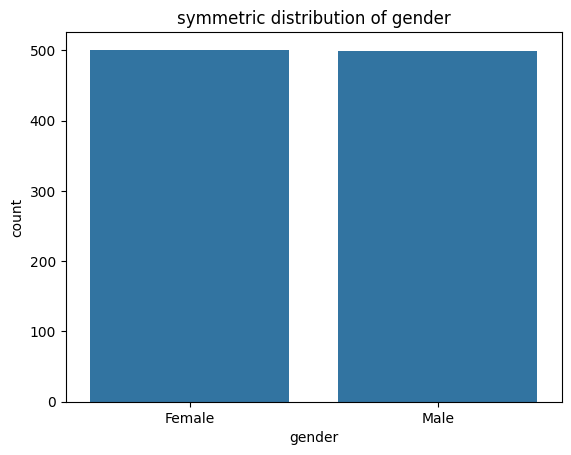

In [58]:
# what is the distributionof gender
gender_count = df['gender'].value_counts()
sns.countplot(data=df,x='gender',order=gender_count.index)
plt.xlabel('gender')
plt.ylabel('count')
plt.title('symmetric distribution of gender')

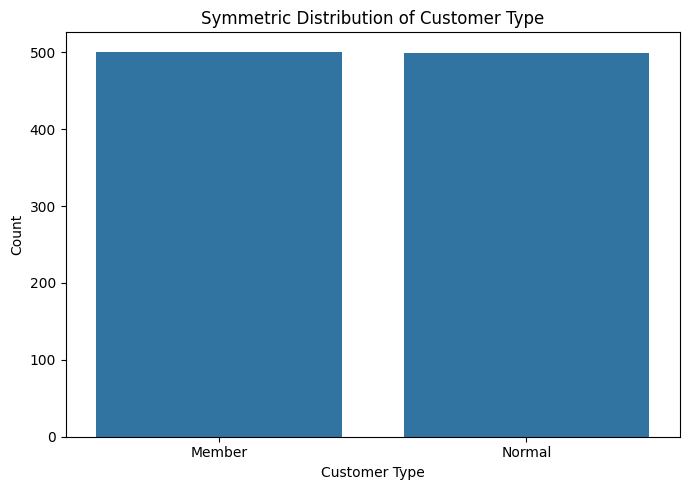

In [59]:
# what is the distibution of customer type
customer_type_counts = df['customer_type'].value_counts()

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='customer_type', order=customer_type_counts.index)
plt.title('Symmetric Distribution of Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_18910/3512053183.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['rating'])


Text(0, 0.5, 'count')

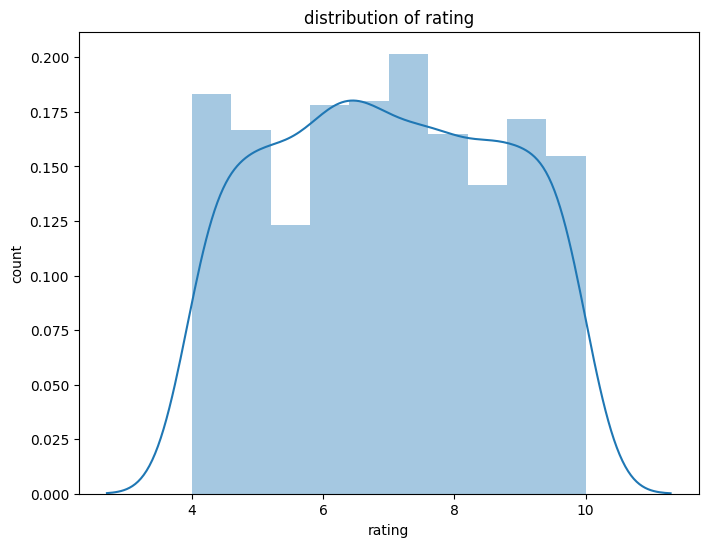

In [60]:
#what is the distribution of rating
plt.figure(figsize=(8,6))
sns.distplot(x=df['rating'])
plt.title('distribution of rating')
plt.xlabel('rating')
plt.ylabel('count')

Text(0, 0.5, 'Product Line')

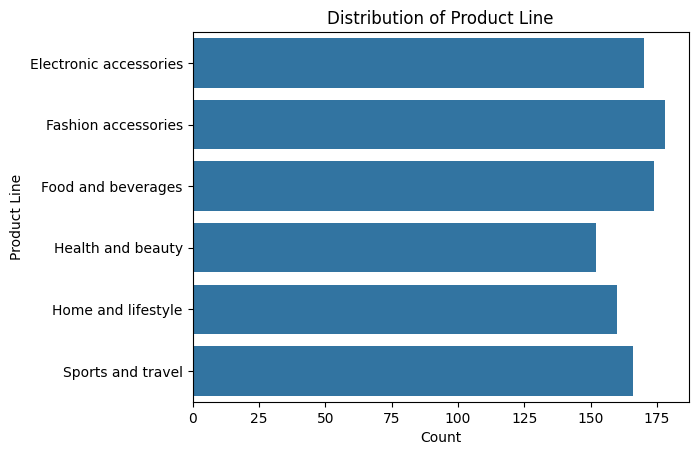

In [61]:
# distribution of productline category
product_line_counts = df['product_line'].value_counts()
sns.barplot(x=product_line_counts.values, y=product_line_counts.index)
plt.title('Distribution of Product Line')
plt.xlabel('Count')
plt.ylabel('Product Line')

Text(0, 0.5, 'City')

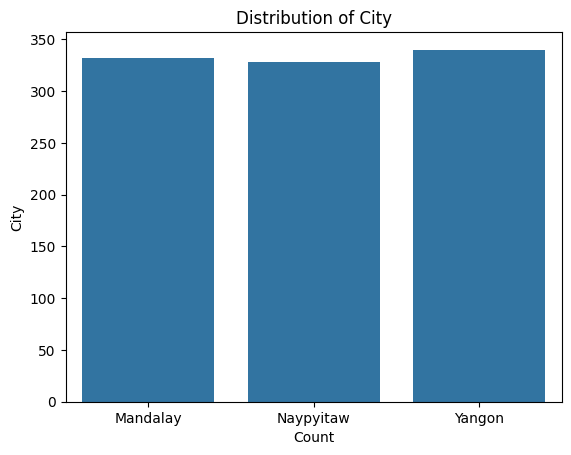

In [62]:
# what is the distribution of city
city_count = df['city'].value_counts()
sns.barplot(y=city_count.values,x=city_count.index)
plt.title('Distribution of City')
plt.xlabel('Count')
plt.ylabel('City')

Text(0, 0.5, 'branch')

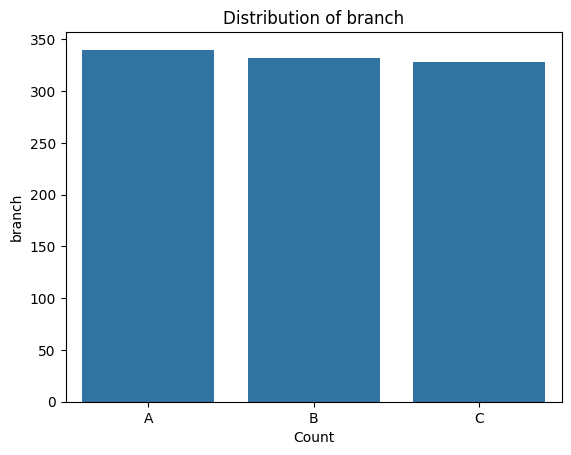

In [63]:
# what is the distribution of branch
branch_count = df['branch'].value_counts()
sns.barplot(y=branch_count.values,x=branch_count.index)
plt.title('Distribution of branch')
plt.xlabel('Count')
plt.ylabel('branch')

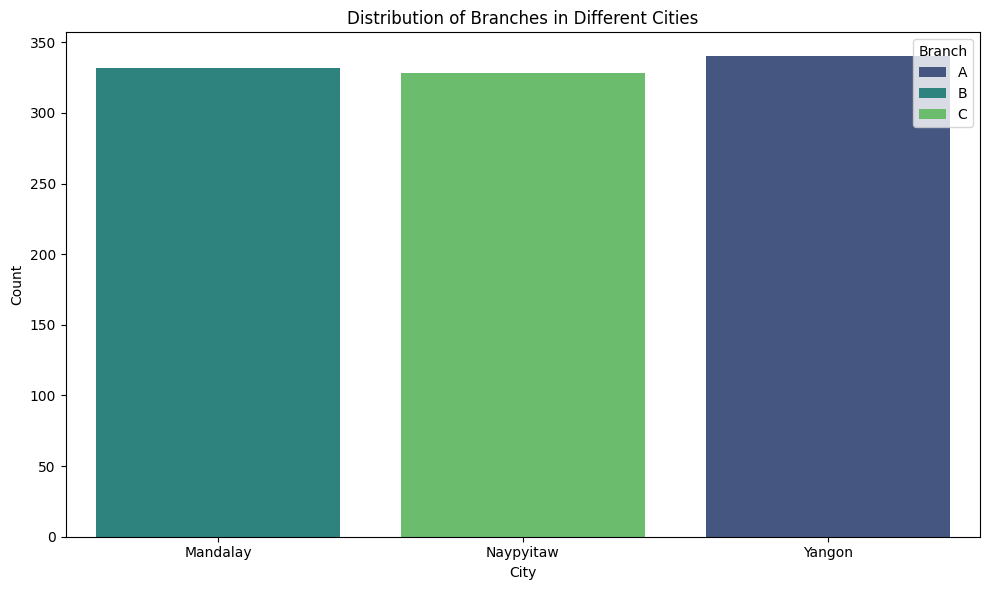

In [64]:
#what is the distribution of branch in different cities
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='city', hue='branch', palette='viridis')
plt.title('Distribution of Branches in Different Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.legend(title='Branch')
plt.tight_layout()
plt.show()

/tmp/ipykernel_18910/4152087357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_total_sales = df.groupby('city')['total'].sum().sort_values(ascending=False)


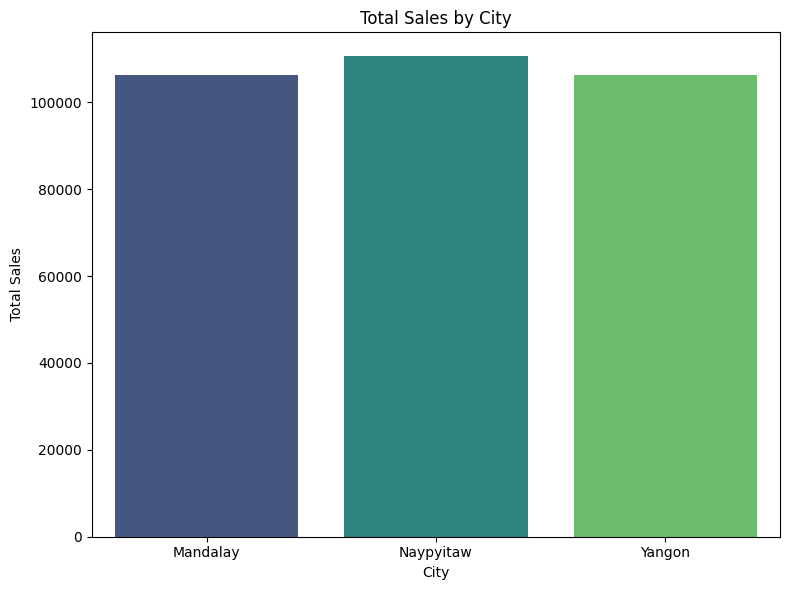

In [65]:
#plot of total in each city
city_total_sales = df.groupby('city')['total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=city_total_sales.index, y=city_total_sales.values, hue=city_total_sales.index, palette='viridis', legend=False)
plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

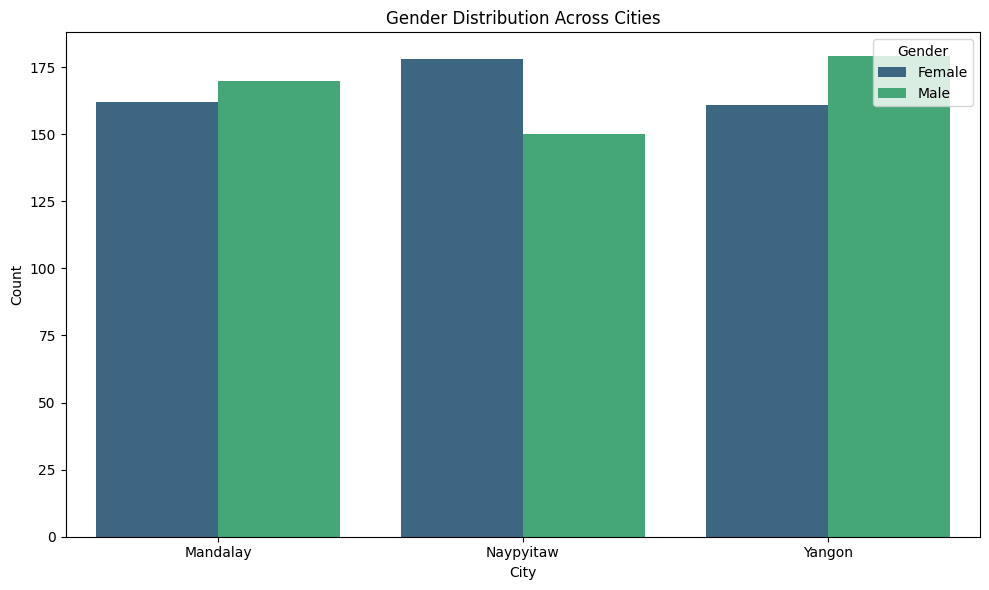

In [66]:
# how gender is distributed among three cities
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='city', hue='gender', palette='viridis')
plt.title('Gender Distribution Across Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

/tmp/ipykernel_18910/4091027275.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gross_income_by_city = df.groupby('city')['gross_income'].sum().sort_values(ascending=False)


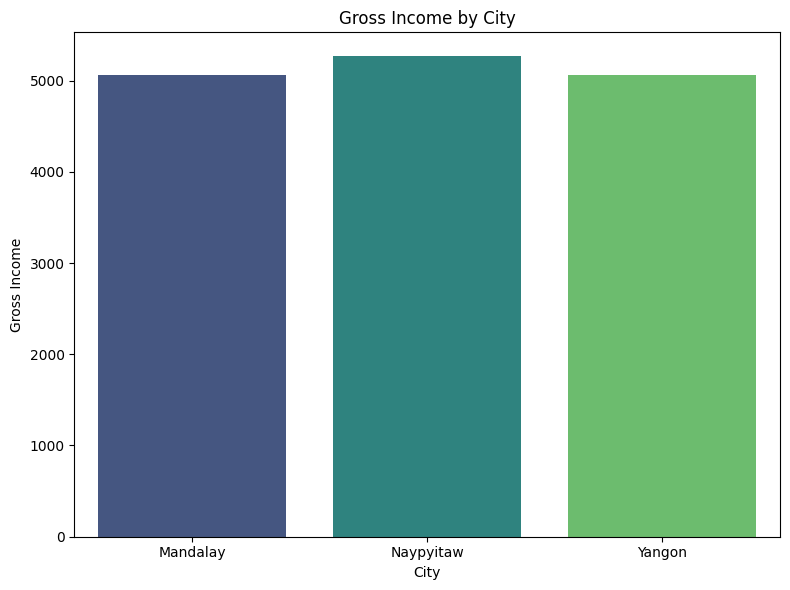

In [67]:
gross_income_by_city = df.groupby('city')['gross_income'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=gross_income_by_city.index, y=gross_income_by_city.values, hue=gross_income_by_city.index, palette='viridis', legend=False)
plt.title('Gross Income by City')
plt.xlabel('City')
plt.ylabel('Gross Income')
plt.tight_layout()
plt.show()

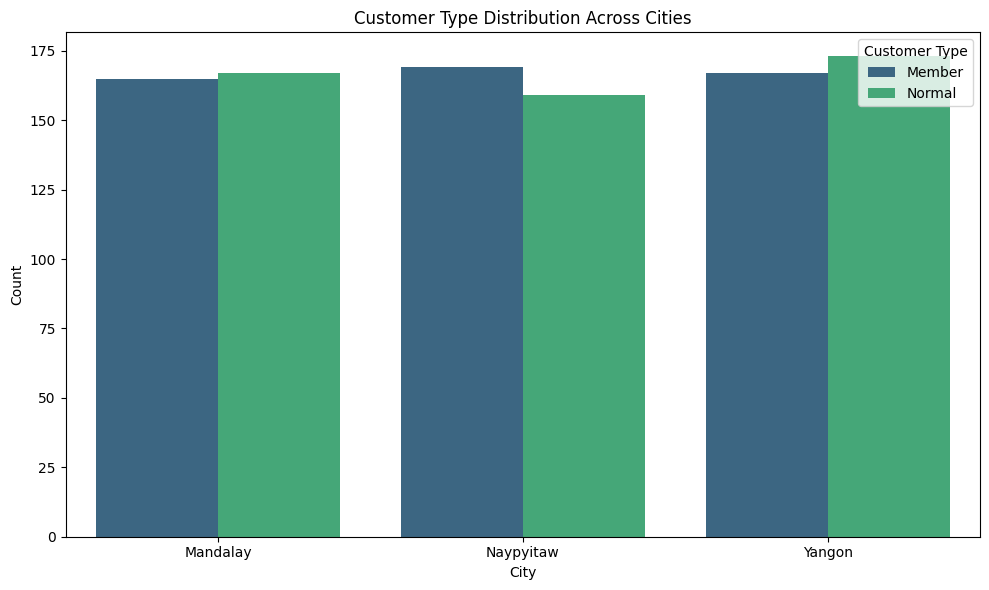

In [68]:
# how customer_type is distributed among each city?
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='city', hue='customer_type', palette='viridis')
plt.title('Customer Type Distribution Across Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

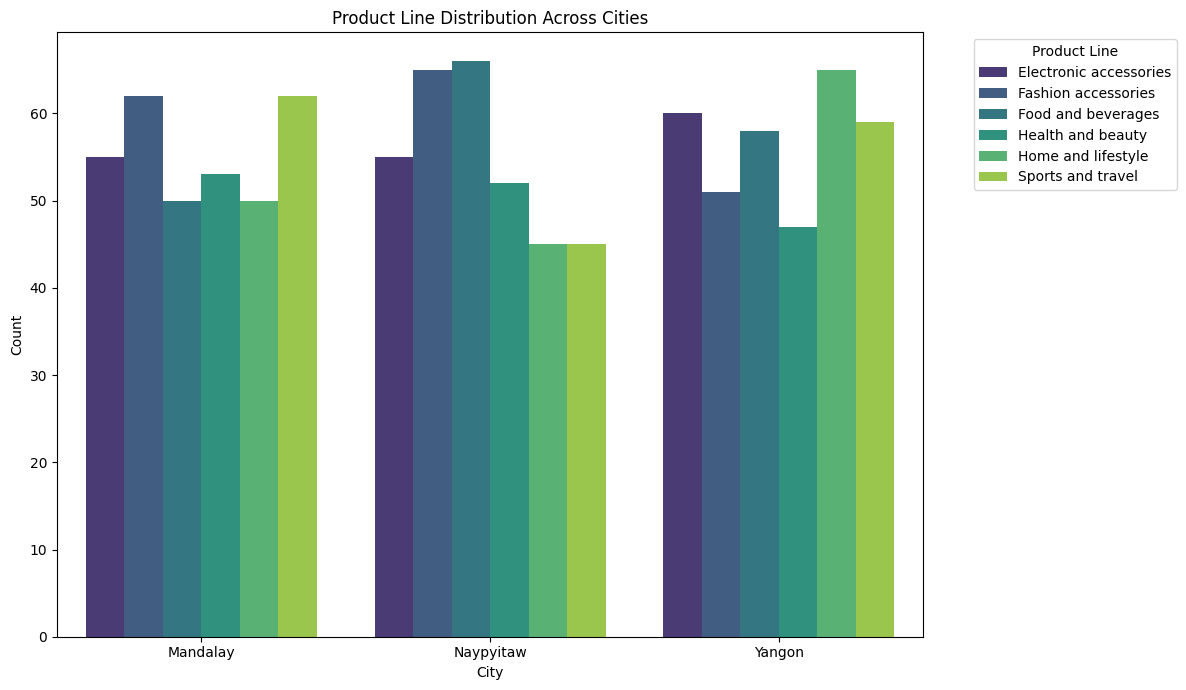

In [69]:
# how product line is distributed in each city
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='city', hue='product_line', palette='viridis')
plt.title('Product Line Distribution Across Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.legend(title='Product Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

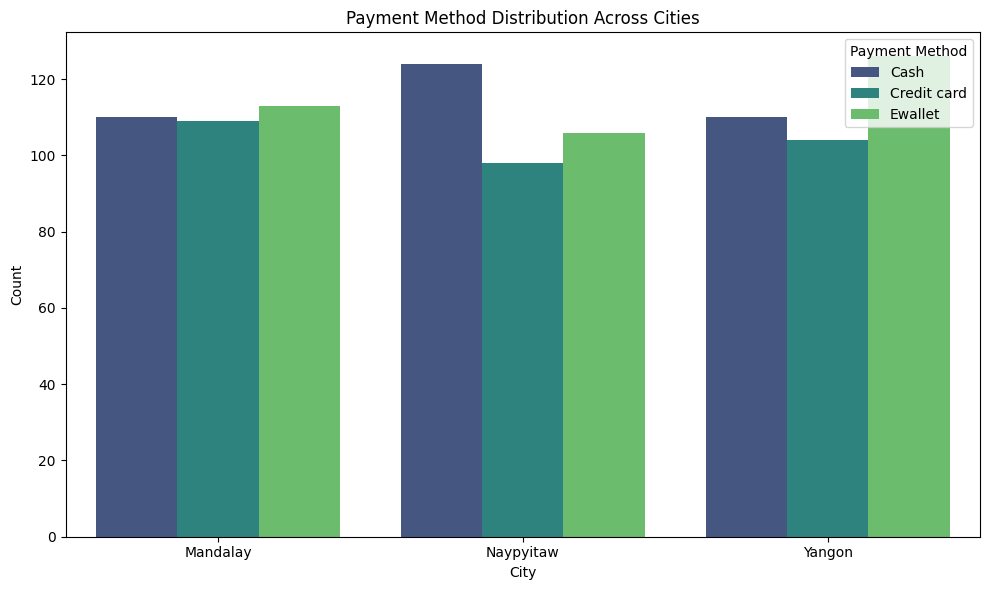

In [70]:
# which payment method customers are more comfortable in each city
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='city', hue='payment', palette='viridis')
plt.title('Payment Method Distribution Across Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.legend(title='Payment Method')
plt.tight_layout()
plt.show()

<Figure size 1400x700 with 0 Axes>

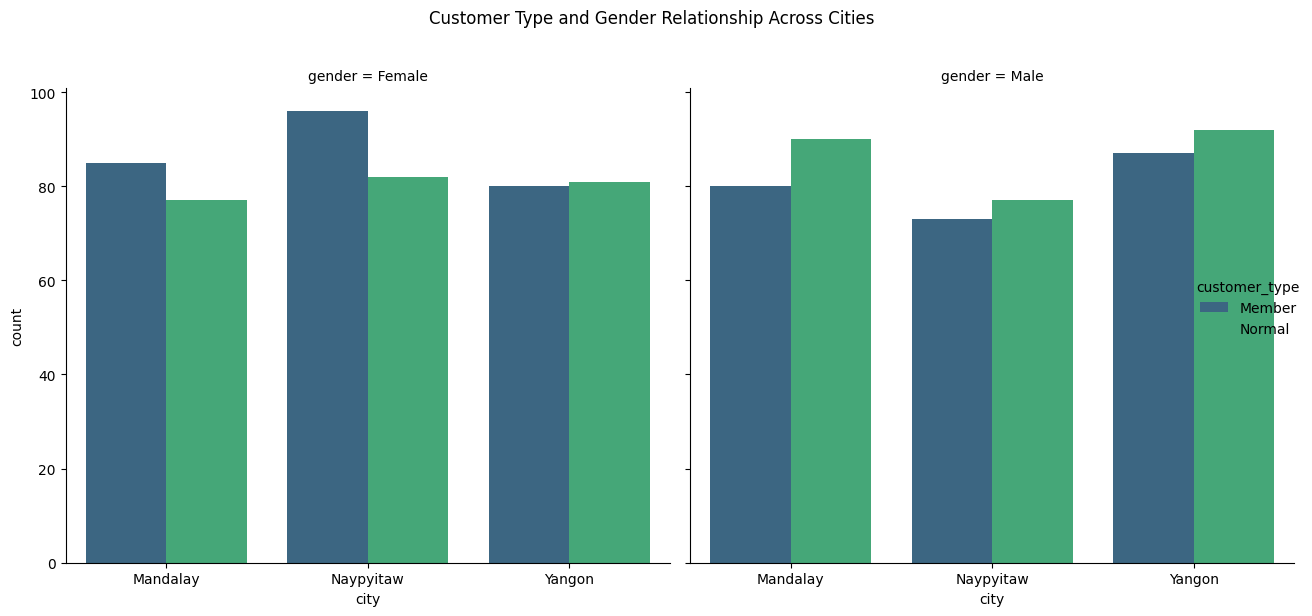

In [80]:
# how customer type and gender are realted in each city
sns.catplot(data=df, x='city', hue='customer_type', col='gender', kind='count', palette='viridis', height=6, aspect=1)
plt.suptitle('Customer Type and Gender Relationship Across Cities', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

Gross Income by City and Branch:
        city branch  gross_income
0   Mandalay      A      0.000000
1   Mandalay      B   5057.032227
2   Mandalay      C      0.000000
3  Naypyitaw      A      0.000000
4  Naypyitaw      B      0.000000
5  Naypyitaw      C   5265.176270
6     Yangon      A   5057.160645
7     Yangon      B      0.000000
8     Yangon      C      0.000000


/tmp/ipykernel_18910/2512703545.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  branch_profitability = df.groupby(['city', 'branch'])['gross_income'].sum().reset_index()


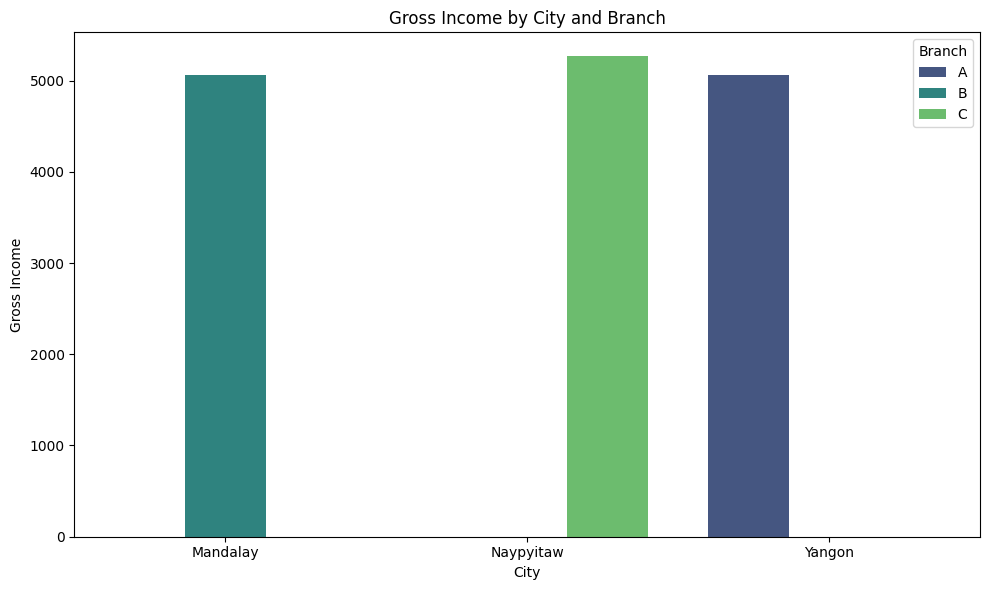

In [86]:
# which branch is more profitable across each city?
branch_profitability = df.groupby(['city', 'branch'])['gross_income'].sum().reset_index()
print("Gross Income by City and Branch:")
print(branch_profitability)

# To visualize the most profitable branch in each city
plt.figure(figsize=(10, 6))
sns.barplot(data=branch_profitability, x='city', y='gross_income', hue='branch', palette='viridis')
plt.title('Gross Income by City and Branch')
plt.xlabel('City')
plt.ylabel('Gross Income')
plt.legend(title='Branch')
plt.tight_layout()
plt.show()

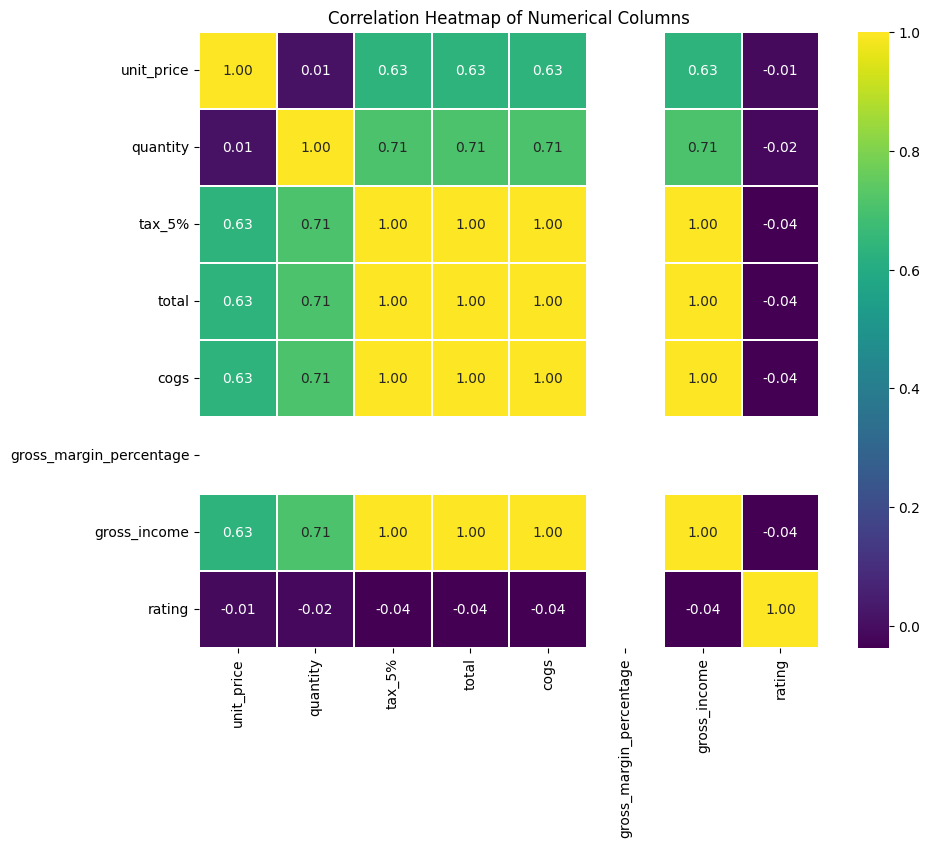

In [84]:
# how all numerical columns are related with each other
numerical_cols = df.select_dtypes(include=['float32', 'int8']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f',linewidths=.05)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

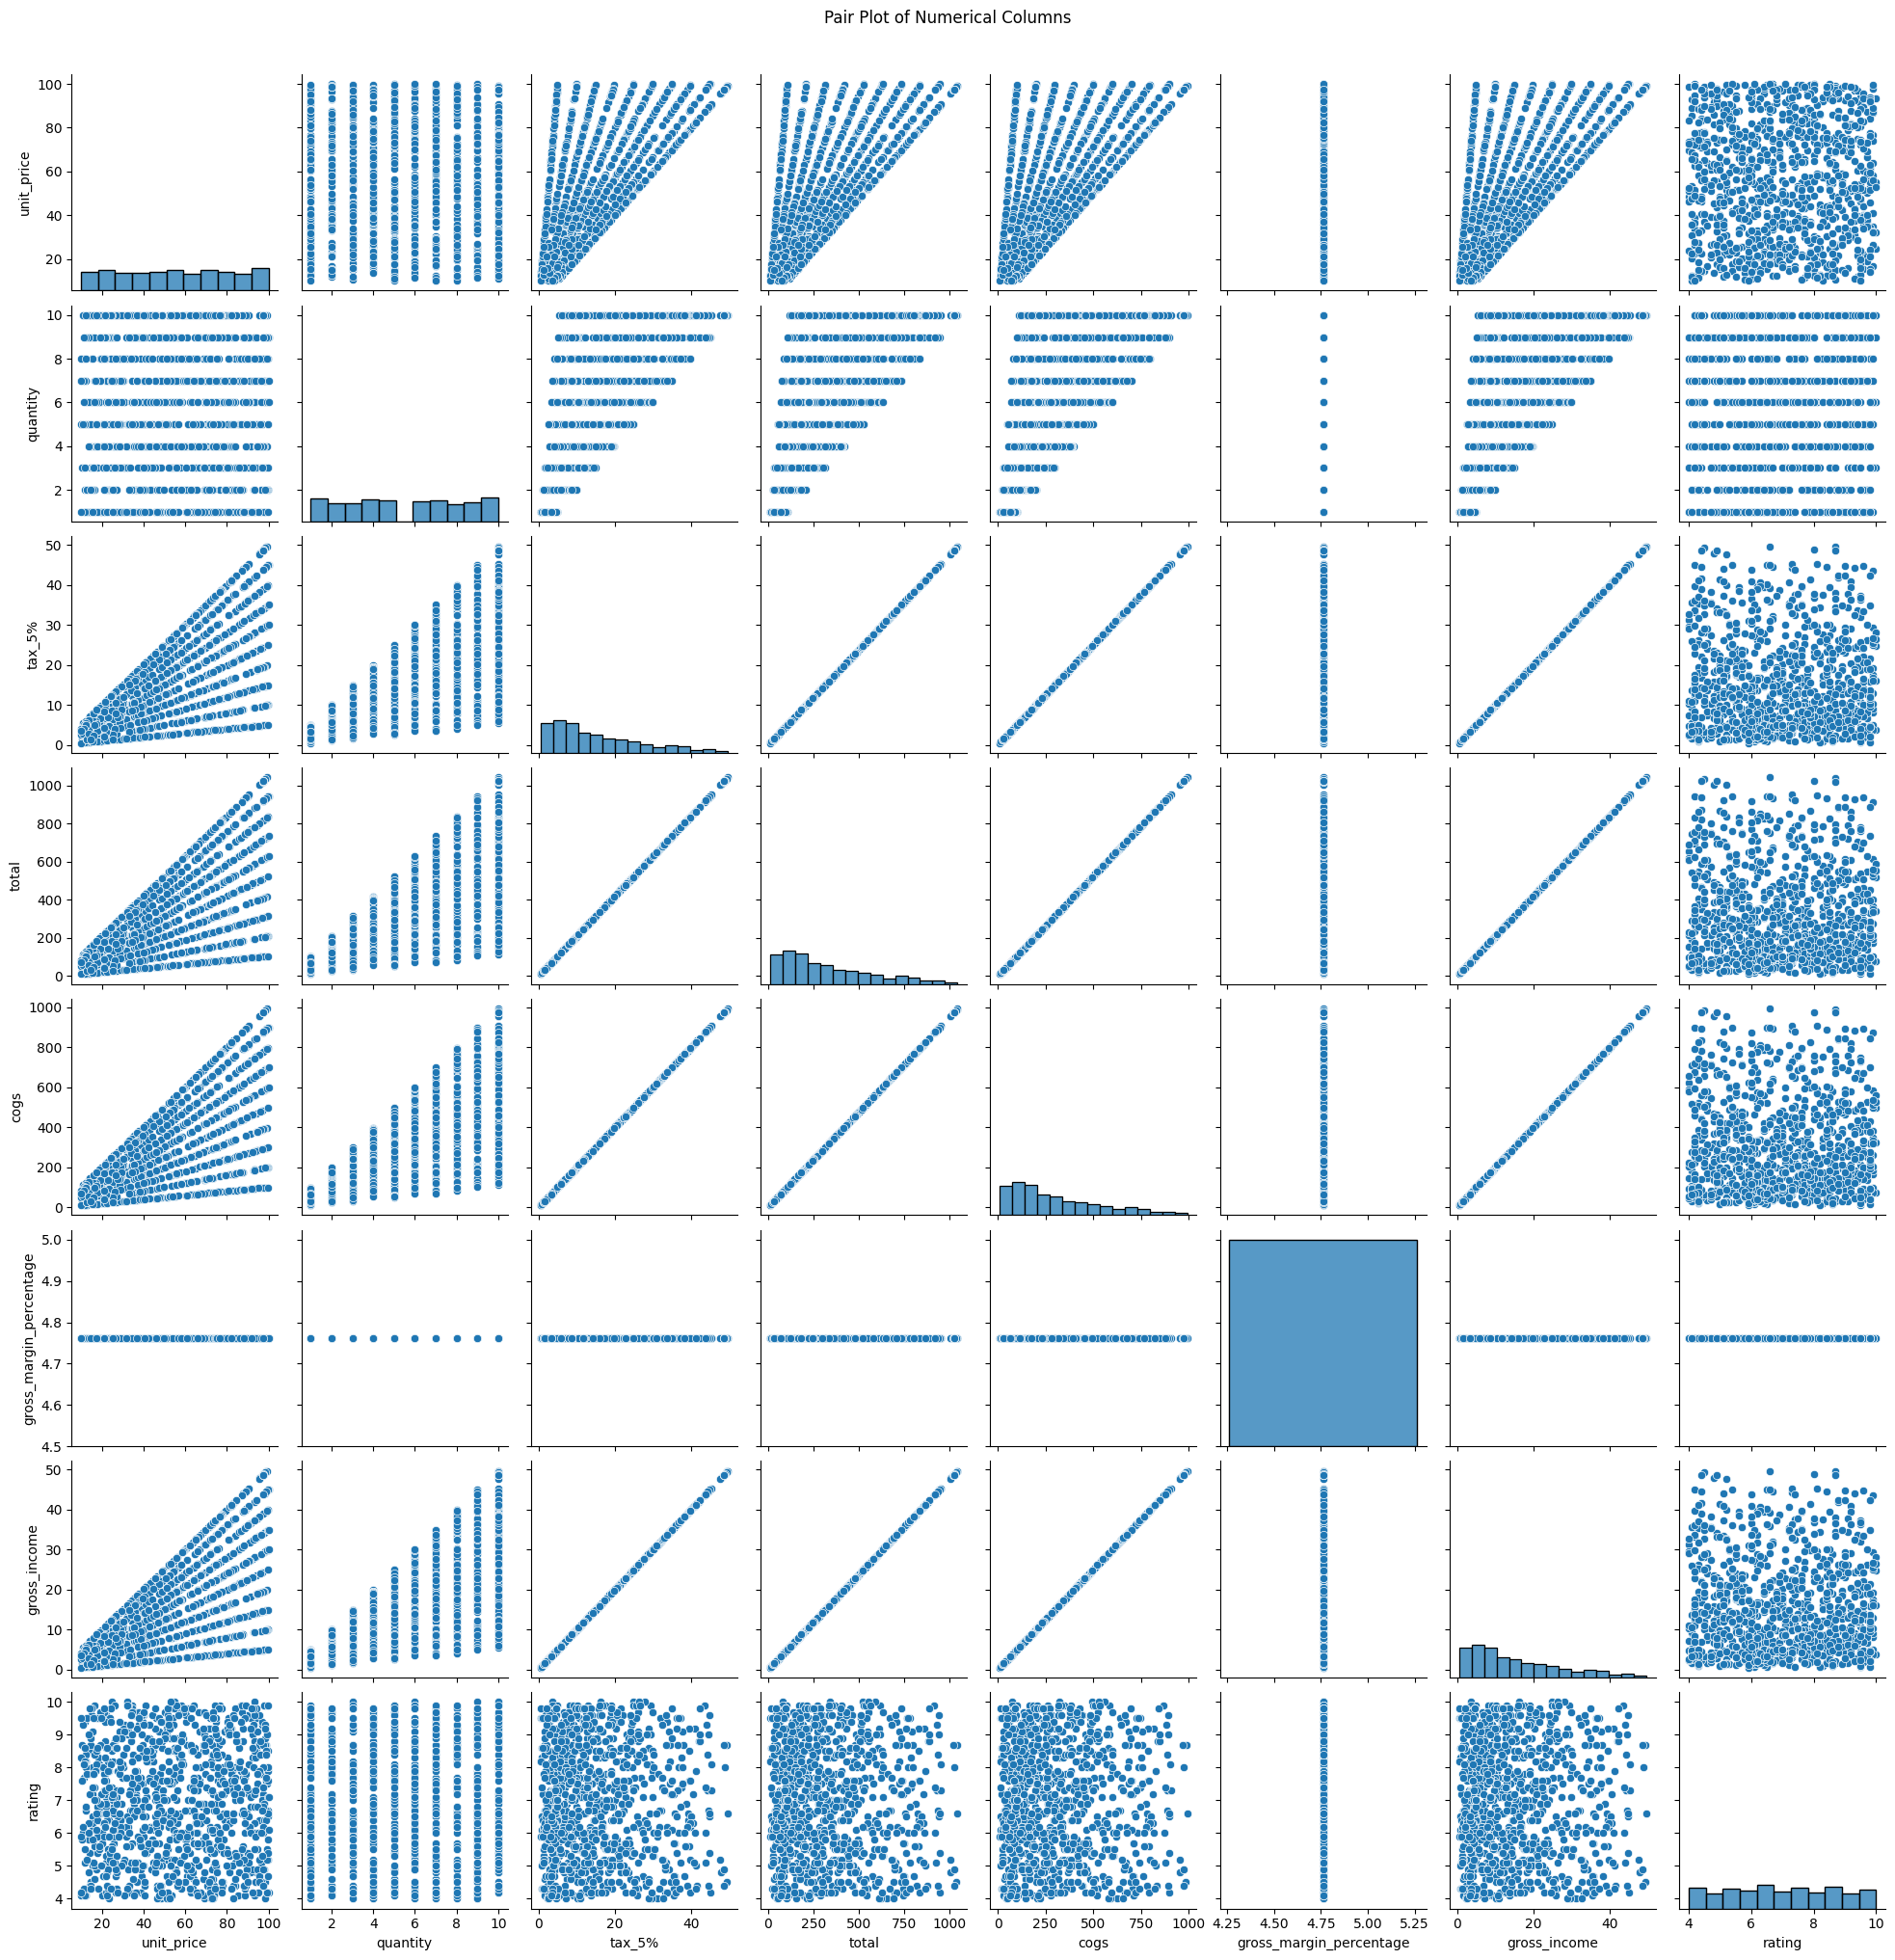

In [87]:
# Select only numerical columns for the pair plot
numerical_df = df.select_dtypes(include=['float32', 'int8'])

# Create the pair plot
sns.pairplot(numerical_df)
plt.suptitle('Pair Plot of Numerical Columns', y=1.02) # Adjust suptitle position
plt.show()

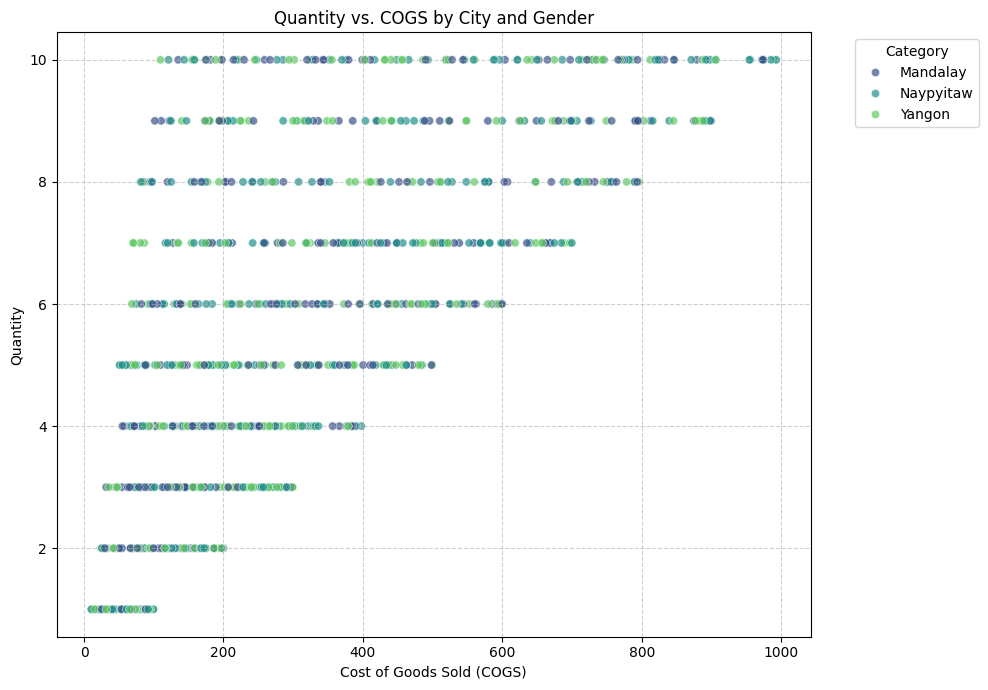

In [92]:
# Quantity vs. COGS by City
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='cogs', y='quantity', hue='city', palette='viridis', alpha=0.7)
plt.title('Quantity vs. COGS by City ')
plt.xlabel('Cost of Goods Sold (COGS)')
plt.ylabel('Quantity')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()